## Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


# 

In [1]:

# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código


In [3]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head

<bound method NDFrame.head of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>

**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
users.isna().sum()


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

In [11]:

# cantidad de nulos para usage
usage.isna().sum()


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador unico de usuario, que no teiene valor analitico.
- La columna `age` representa un valor de -999, este dato es invalido porqu eno es un valor real, esto presenta un sentinel (Valor falso) utilizado para representar los datos faltantes. Aqui se tendria que reemplazar el -999 por nulo (NaN) para su tratamiento.

In [13]:

# explorar columnas numéricas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no represntan variables de consumo, sino identificadores.
- Las columnas `dutation` y `length` son variables de consumo:
  `dutation`: Tiene valores de 0 a 120, con una media de 5.20 y una mediana 3., por lo que sugiere una distribucion sesgada a la derecha, con algunos valores altos que representarian outliers.
  `length`:Muestra valores de 0 a 1490, con una media de 52.12 y mediana de 50, la diferencia es grande por lo que los valores podrian afectar el analisis.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


In [15]:
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [16]:
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` representa diferentes categorias de ciudades. En este punto es necesario verificar que no existian insconsistencias en la escritura por ejemplo: caracteres especiale, minusculas/ Mayusculas y espacio, entre otras.
- La columna `plan` muestra los tipos de planes disponibles para los usuarios, los valores parecen ser consistentes y representan categorias claras, no muetran detalles.

In [17]:


# explorar columna categórica de usage
usage['type'] # completa el código


0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object

In [18]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` tiene 2 categoria:
  `tex:` 22092 registros
  `call:` 17908 registros
  Estos representan los tipos de uso del servcio. no observo valores inconsistentes que afecten el analisis.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =  pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [21]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, muestra la distribucuion de los años registrados de los usuarios, la mayoria de los registros son del año 2022 al 2024, estos datos son consistentes con el periodo esperado del analisis.
Tambien se tiene identificado 40 registros del año 2026, que se encuentra fuera de rango de datos validos del proyecto, puede ser un posible error de catura de datos.

In [22]:


# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()



2024.0    39950
Name: date, dtype: int64

En `date`, del dataset `usage` se observa que todos los registros se concentran en el año 2024.
Basaremos el análisis en estas fechas. sin presencia de registros en otros periodos.
Por lo que se utilizaran estas fechas como base para el analisis temporal del consumo de servicios. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [25]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [27]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Las columnas `duration`, los valores nulos se encuentran casi exclusivamente en el tipo text (≈99.9%), mientras que en call practicamente no exiten nulos.
 En cambio en la columna `length` ocurre lo contrario: los valores nulos se encuentran en call (≈99.9%), mientras que en text no presentan nulos relevantes.
Este comportamiento nos indica que los valores faltantes no son aleatorios, sino que dependen directamente del tipo de servicio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'cant_text': 'cant_mensajes',
    'cant_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01




Se agrupo el dataset de usurios con la tabla agregada para construir un perfil completo de cada cliente,
Esto nos ayudara para analizar el comportamineto en terminos de mensajes, llamadas y consumo de minutos.



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

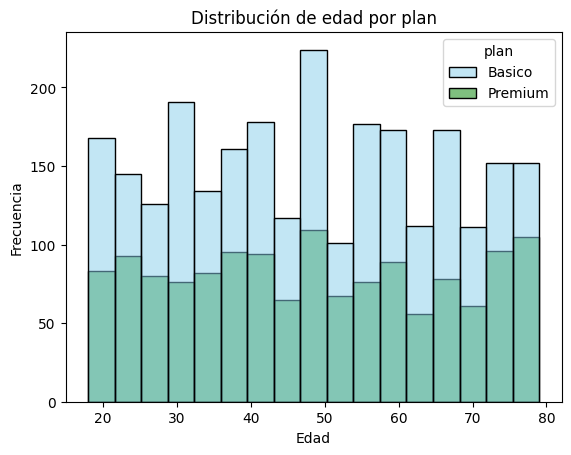

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- Distribución de la edad muestra que los usuarios estan relativamente bien distribuidos entre los 20 y los 75 años, sin concentrarse en un rago especifico, se puede observar a simple vista que hay un ligero pico entre los 45 y los 50 años lo que indica que hay una mayor concentracion de usuarios en ese rango.
  No se aprecian diferencias entre los planes Básico y Premium, ambos se muestran patrones similares a lo largo de las edades.

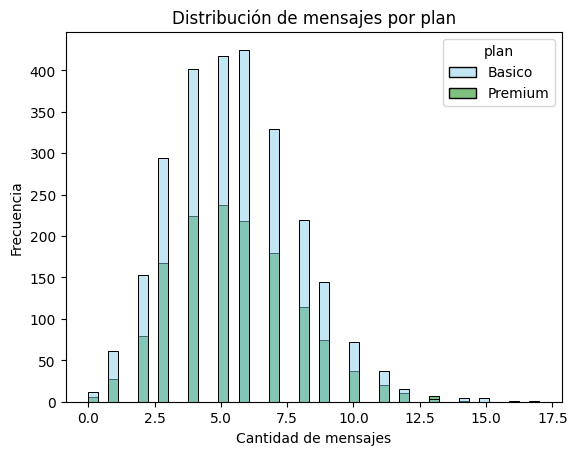

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- La distribución muestra la cantidad de mensanjes que envia la mayoria de los usuarios son pocos mientras que un grupo reducido muestra un alto consumo. La grafica se muestra sesgada a la derecha , se logra apreciar que hay presencia de usuarios intensivos. Asi mismo, los usuarios del  plan premium tiende a concentrase en niveles mas altos de consumo en comparacion de los del plan Basico.

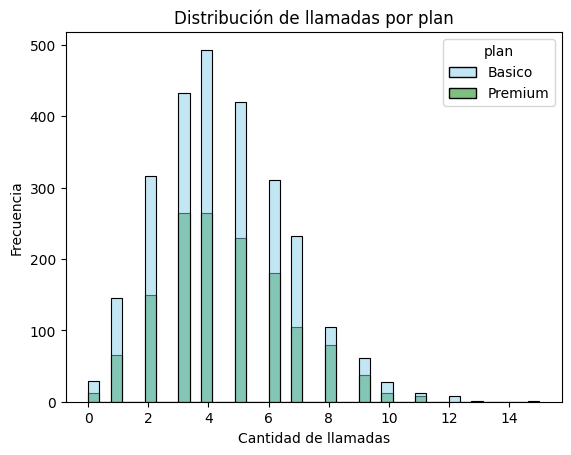

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- Distribución de  llamadas que la mayoria de los usuarios realiza pocas llamadas mientras que un grupo reducido presenta un alto uso de llamadas,esta distribucion esta sesgada a la derecha, lo que indica la presencia de usuarios intensivos.

  Se muestra que el los usuarios con plan premiun tienden a realizar mas llamadas en comparacion con los del plan basico.

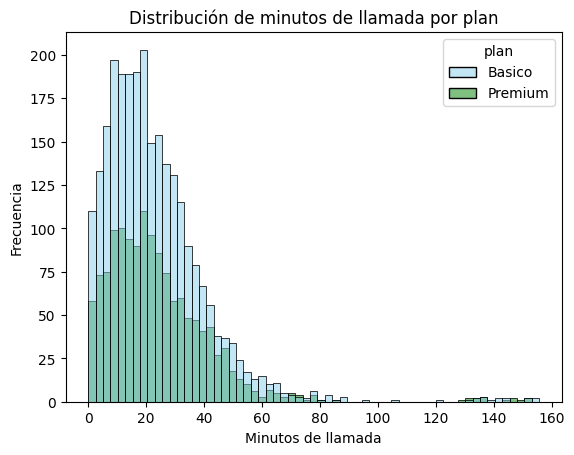

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
- Esta distribucion muestra que la mayoria de los usuarios consumen pocos minutos mientras que un gruopo reducido presenta un alto consumo. por es arazon la distribucion se encuentra sesgada hacia la derech. Se observa que los usuarios con plan premuin tienden a consumir mas minutos en comparacion de los usuarios del plan basico.

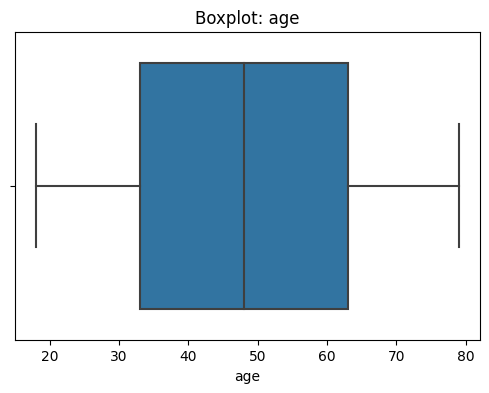

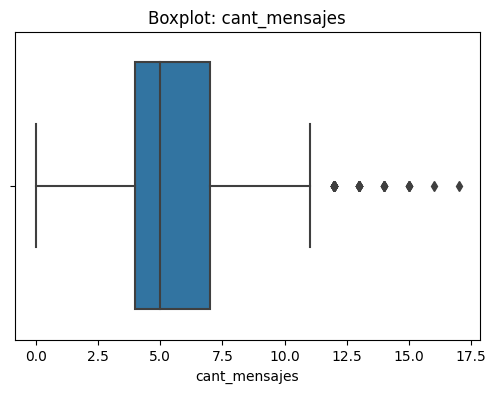

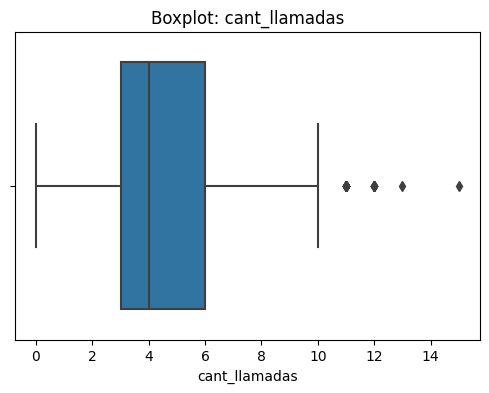

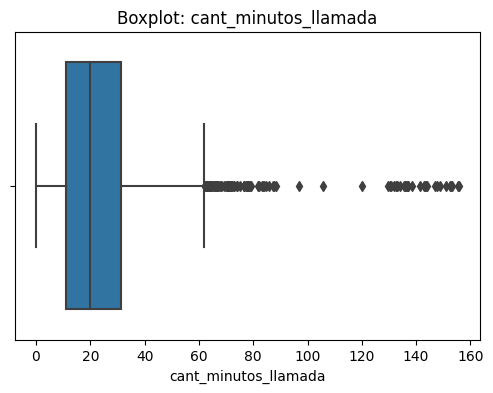

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()




### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

💡Insights: 
- Age: Presenta pocos outliers. He observado algunos valores extremos en edades mas altas o mas bajas, pero en general la distribución es bastante estable y se muestra bien la poblacion de usuarios.
- cant_mensajes: Tienen varios outliers. Existen usuarios con un número de mensajes significativamente mayor al promedio, muestra un grupo de usuarios muy activos en el servcio de mensajes.
- cant_llamadas: Presenta varios outliers. Hay usuarios con una cantidad de llamadas mucho mayor al resto, lo que se puede observar es que la mayoria de los valores se concentran en rangos bajos o medios.
- cant_minutos_llamada: Presentan outliers, Muestra usuarios con tiempos de llamada muy elevados en comparacion con la mayoria, hay usuarios con alto consumo de servicio.

In [38]:
# Calcular límites con el método IQR
columnas_limites = [
    'age',
    'cant_mensajes', 
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\nColumna: {col}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")




Columna: age
Límite inferior: -12.0
Límite superior: 108.0

Columna: cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5

Columna: cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5

Columna: cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [39]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Es recomendable matener los outliers, porque presenta usuarios de mensajeria muy altos. Estos valores reflejan comportamientos real de usuarios intensivos y pueden ser importantes para el analisis del uso del servicio.
- cant_llamadas: mantener o no outliers, porqué? se recomienda mantener los outliers, debido a que existen usurios con un a gran cantidad de llamadas siginificamente mayor al promedio. Estos casos no son errores, si no variaciones naturales en el uso de servicio.
- cant_minutos_llamada: mantener o no outliers, porqué? Es recomendable matener los outliers, ya que reflejan  clientes con tiempos de llamda muy elevados. Estos valores representan usuarios de alto consumo y son relevantes para entender los distintos perfiles fe comportamiento.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [41]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

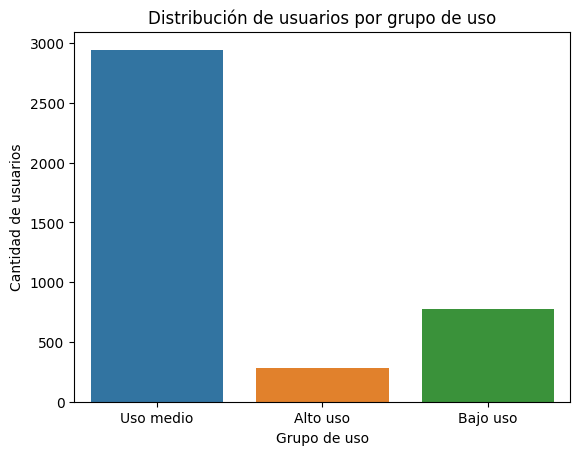

In [44]:

# Visualización de los segmentos por uso
sns.countplot(x='grupo_uso', data=user_profile)


plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


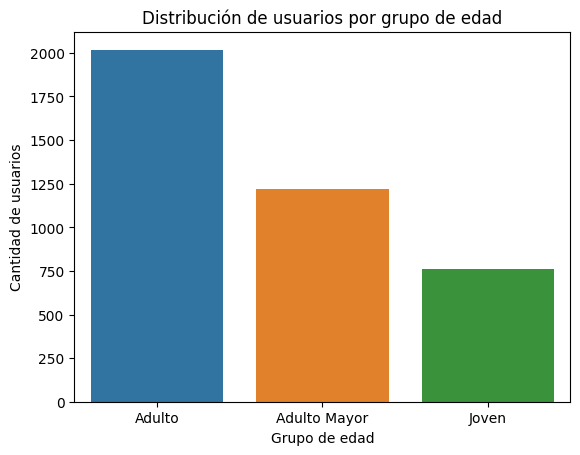

In [45]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
En este analisis se identificon valores faltantes en la variable city e inconsistencias en algunos datos antes de la limpieza y agregación. En terminos generales, el porcentaje de valores faltantes no era critico, pero si requeria tratamiento para evitar sesgos en el análisis. Tambien encontre que los datos de uso estaban a nivel tradicional, por lo que fue necesario agregarlos por usuario para obtener una visión más clara del comportamiento.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso? Se identificaron 2 tipos de segmentación:

  Por uso:
         Bajo uso: Muestra usuarios con poca actividad en llamadas y mensajes.
         Uso medio: Se muetra usuarios con actividad moderada.
         Alto uso: Muestra usuarios con alto consumo de llamadas y mensajes.

  Por edad:
         Joven: Muestra una actividad menor en general, pero mas uso de mensajeria.
         Adulto: Se visualiza un grupo mas equilibrado en el uso de servicio.
         Adulto: Muestra una menor cantidad de usurios, pero con uso más estables.
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  Los  segmentos más valiosos son los usuarios de alto uso, mismos que generan mas consumo de minutos y mensajes, lo que reprentaba mayor ingreso potencial para la empresa. Dentro de este grupo los adultos, se mantienen por su contancia y uso de servicio,  esto lo hace ser impotantes deltro del analisis.

  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio? Se logro identificar outliers principalmente en cant_mensajes, cant_llamadas y cant_minutos_llamada. Esto representa usuarios con un nivel de consumo bastante significativo por encima del promedio. Lejos de ser errores estos valores reflejan clientes intensivos que tienen un impacto importante en el consumo total de servicio.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
 Estructurar y ofrecer un plan premium para usuarios de alto uso, especialmente en llamadas y mensaje.
 Hacer una buena estrategia para crear promociones para usuarios de uso medio que lo haga migrar a un plan con mas beneficios.
 Se debe hacer una estrategia para retencion de usuarios jovenes con alto uso, mismos que representan potencial de crecimiento  a largo palzo.
 considerar planes flexibles basados en consumo real en consumo real para mejorar la satisfacción del cliente.



✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores faltantes en la variable city, esto no afectan directamente el análisis principal.
  Además, los datos de uso del servicio se encontraban a nivel transaccional, por lo que fueron tratados. También se detectaron valores atípicos (outliers) en variables de uso como mensajes, llamadas y minutos, lo cual refleja       comportamiento de los usuarios.


🔍 **Segmentos por Edad**
- abc
- Se identificaron tres segmentos: Bajo uso, Uso medio y Alto uso.
  El grupo de alto uso representa a los usuarios más activos, con mayor cantidad de llamadas, mensajes y minutos consumidos.
  El grupo de bajo uso corresponde a clientes con interacción limitada con el servicio.


📊 **Segmentos por Nivel de Uso**
- En el analisis Se identificaron tres segmentos: Bajo uso, Uso medio y Alto uso.
  En el grupo de alto uso representa a los usuarios más activos, con mayor cantidad de llamadas, mensajes y minutos consumidos.
  En el grupo de bajo uso corresponde a clientes con interacción limitada con el servicio.


➡️ Esto sugiere que ...
 El comportamiento de los usuarios no es uniforme y existe diferencias claras en el nivel de consumo del servicio.
 Los usuarios de alto uso representan el segmento más valioso para la empresa, ya que generan mayor actividad y potencial de    ingresos.
 Existe una oportunidad importante de convertir usuarios de uso medio en alto uso mediante estrategias de mejora de planes.

💡 **Recomendaciones**
- Estructurar planes especificos para usuario de alto uso con mayor capacidad de llamadas y mensajes.
- Implementar estrategias para usuarios de medio uso.
- Ofrecer planes mas flexibles basados en consumoreal para mejorar la retencion.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`